<a href="https://colab.research.google.com/github/luzangelacarabali/Python_Cursos/blob/main/Notebooks/Sesion_6_Sesion_7_GoogleDrive_API_OrienteStereo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎙️ Python Schools 2026 — Sesion 6 y 7
###☁️ Sesiones 6 + 7 **Google Drive API · Autenticación · Backup real**

---
## 🗺️ ¿Dónde estamos?

| Sesión | Componente | Estado |
|--------|-----------|--------|
| S1–S4 | Entorno · Normalización · Filtros · Escaneo | ✅ |
| S5 | `catalogo.py` — DataFrame completo con pandas | ✅ |
| **S6** | **🔑 Autenticación OAuth 2.0 · credenciales · tokens** | ⬅️ Ahora |
| **S7** | **☁️ Subir archivos a Drive · verificar cuota · log** | ⬅️ Después |
| S8 + S9 |  `main.py` completo + entrega | ⏳ |

---

## 🎯 Objetivos de esta sesión doble

Al terminar vas a poder:

1. Explicar qué es OAuth 2.0 y por qué Google lo usa
2. Distinguir entre `credentials.json` y `token.json`, y saber cuál va al repositorio
3. Conectarte a la API de Google Drive desde Colab.
4. Consultar el espacio disponible en un Drive real
5. Subir archivos verificando cuota antes de cada subida
6. Leer el catálogo CSV y marcar archivos como respaldados
7. Plantear la lógica de priorización de tandas (ejercicio abierto)

---

## 🚨 Contexto real

Oriente Stereo ya perdió parte de su archivo por daño físico de equipos.
El Drive de la emisora está al **80% de capacidad** (~15 GB total → ~3 GB libres).
Estas sesiones responden a pérdidas reales ya ocurridas. No son funcionalidades opcionales.

---
## ⚙️ Parte 0 — Instalación y librerías
⏱ *5 minutos*

In [1]:
# En Colab estas librerías ya vienen instaladas.
# Si trabajas en tu computador local, descomenta y ejecuta:
# !pip install google-auth google-auth-oauthlib google-auth-httplib2 google-api-python-client pandas

import pandas as pd
from pathlib import Path
from datetime import datetime
import os, json, io

# Verificar versiones
import google.auth
import googleapiclient
print("✅ google-auth          :", google.auth.__version__)
print("✅ google-api-python-client instalado")
print("✅ pandas               :", pd.__version__)
print()
print("Todo listo para conectarnos a Google Drive.")

✅ google-auth          : 2.47.0
✅ google-api-python-client instalado
✅ pandas               : 2.2.2

Todo listo para conectarnos a Google Drive.


---
## 🌐 Parte 1 — ¿Qué es una API y por qué la necesitamos?
⏱ *15 minutos — explicación*

### API = Application Programming Interface

En español: **Interfaz de Programación de Aplicaciones**.
Permite la interaccion entre aplicaciones software

Una API define un conjunto de reglas y funcionalidades para que dos sistemas se comuniquen entres sí. Los sistemas pueden interactuar para intercambiar o manipular datos. No tratamos con la API si no con la interfaz de usuario para interacturar con las aplicaciones y en esencia todos los sistemas se construyen con API.

Es la forma en que dos programas se comunican entre sí sin que ninguno tenga que conocer el código interno del otro.
Por ejemplo:

Cuando enviamos un correo y hacemo clic en el boton 'send', la aplicación de correo usa una API para indicarle al servidor de correo que envíe un mensaje la destinatario.

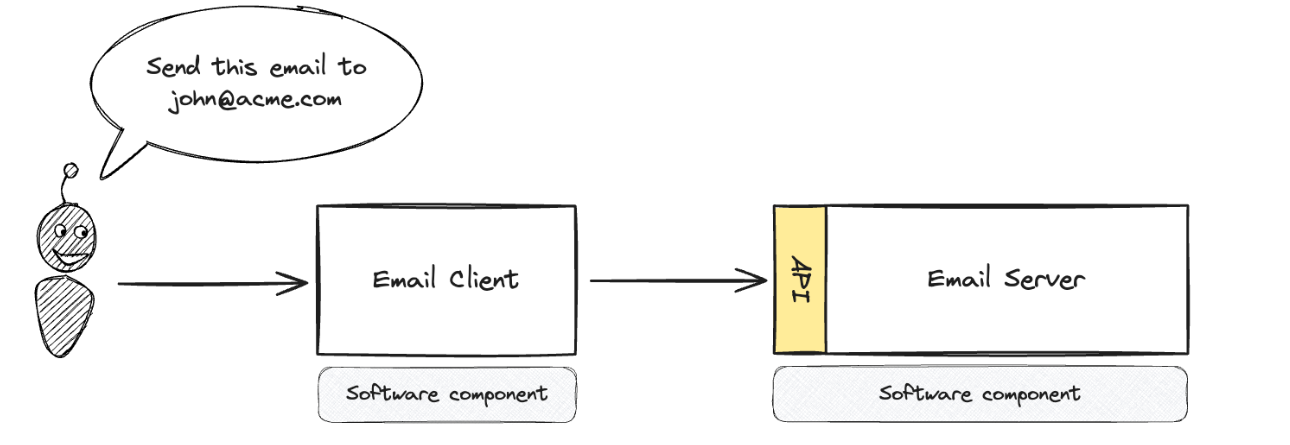


Para el desarrollo de nuestro mvp para la emisora nos conectaremos a la nube de Google para almacenar el archivo/programa


```
Tu programa Python  ──►  Google Drive API  ──►  Servidor de Google
                  ◄──                    ◄──
                   "archivo subido OK"        (almacena el archivo)
```

### ¿Por qué no simplemente copiar los archivos a la carpeta de Drive?

Cuando abres Google Drive en el navegador y arrastras un archivo, **tú** estás haciendo esa acción manualmente. La API permite que un **programa Python** haga exactamente lo mismo, pero:

- Sin abrir el navegador
- Sin intervención manual
- Con lógica: verificar espacio, registrar log, reintentar si falla
- Automatizado: puede correr a las 2 AM sin que nadie esté despierto

### ¿Qué puede hacer la Drive API?

| Acción | Método API | Para Oriente Stereo |
|--------|-----------|-------------------|
| Consultar espacio libre | `about().get()` | Saber si caben los archivos antes de subir |
| Subir un archivo | `files().create()` | Respaldar audios |
| Listar archivos | `files().list()` | Verificar que el backup existe |
| Crear carpeta | `files().create()` | Organizar por programa |
| Descargar archivo | `files().get_media()` | Recuperar archivos si el disco falla |

### ¿Esto se debe hacer también en la radio?

**Sí.** Lo que construimos en Colab hoy es exactamente lo que correrá en el computador de Oriente Stereo. La diferencia es:

| En Colab (hoy) | En la radio (producción) |
|---------------|------------------------|
| Cuenta de prueba / cuenta personal | Cuenta oficial de Oriente Stereo |
| Credenciales de prueba | Credenciales reales de la emisora |
| Archivos simulados | Archivos reales del archivo sonoro |
| Se ejecuta manualmente | Se ejecuta con `python main.py --backup-drive` |

---
## 🔑 Parte 2 — OAuth 2.0: credenciales, tokens y seguridad
⏱ *25 minutos — la parte más importante*

### ¿Qué es OAuth 2.0?

OAuth 2.0 es el protocolo que usa Google para dejar que un programa externo acceda a una cuenta sin que el programa conozca la contraseña.

```
Analogía: es como darle a alguien una llave de repuesto de tu casa.
La llave solo abre la puerta trasera (el Drive), no la puerta principal
(tu cuenta completa con Gmail, fotos, etc.).
```

### El flujo completo — una sola vez

```
1. Tú vas a Google Cloud Console y registras tu aplicación
   → Google te da credentials.json  (la "descripción" de tu app)

2. La primera vez que corres el script:
   → El script abre el navegador
   → Tú inicias sesión en Google y le das permiso a la app
   → Google genera token.json  (la "llave de repuesto")

3. Las veces siguientes:
   → El script usa token.json directamente
   → No vuelve a abrir el navegador
   → Si el token vence, se renueva automáticamente
```

---

### `credentials.json` vs `token.json` — diferencias críticas

| | `credentials.json` | `token.json` |
|--|-------------------|-------------|
| **¿Qué es?** | Identidad de la aplicación | Permiso de acceso a UNA cuenta |
| **¿Quién lo genera?** | Tú, en Google Cloud Console | Se genera automáticamente al autenticar |
| **¿Cuánto dura?** | No vence (a menos que lo revoques) | Vence, pero se renueva solo |
| **¿Contiene contraseña?** | No | No — es un token, no una contraseña |
| **¿Va al repositorio GitHub?** | ❌ NUNCA | ❌ NUNCA |
| **¿Va al `.gitignore`?** | ✅ SÍ | ✅ SÍ |
| **¿Se comparte entre computadores?** | Sí, con cuidado | No — es específico de cada máquina/cuenta |

---

### ¿Por qué NUNCA subir estos archivos a GitHub?

Si alguien obtiene tu `credentials.json` + `token.json`:

```
❌ Puede leer TODOS los archivos de tu Drive
❌ Puede subir archivos
❌ Puede borrar archivos
❌ Y tú no te enterarías hasta revisar el log de acceso de Google
```

GitHub es público por defecto. Cualquier bot que escanea repositorios puede robar estas claves en segundos.

---

### Alcances (Scopes) — el principio de mínimo privilegio

No le damos a la app acceso a TODO Google. Solo a lo que necesita:


```python
# ❌ Demasiado permiso — acceso a TODO el Drive
SCOPES = ['https://www.googleapis.com/auth/drive']

# ✅ Solo archivos que la propia app creó — suficiente para backup
SCOPES = ['https://www.googleapis.com/auth/drive.file']
```
Es una lista que le dice a Google qué permisos le estás pidiendo a la API. Es como cuando una app del celular te pide acceso a la cámara, tú decides si se lo das o no.
drive.file específicamente significa: "solo puedo ver y modificar los archivos que yo mismo subí con este script". No puede leer tu Gmail, no puede ver fotos personales, no puede tocar documentos que tú creaste manualmente en Drive.

Si usaras drive en cambio (sin el .file), tendría acceso a todo el Drive. Por eso usamos el scope más restrictivo posible.


`drive.file` significa: "solo puedo ver y modificar los archivos que yo mismo subí". El equipo de Oriente Stereo no necesita más que eso para el sistema de backup.

---

### ¿Cómo configurar las credenciales para la radio? — paso a paso

```
1. Ir a: https://console.cloud.google.com
2. Crear proyecto nuevo: "OrienteStereoBackup"
3. Menú lateral → APIs y servicios → Biblioteca
4. Buscar "Google Drive API" → Habilitar
5. Menú lateral → APIs y servicios → Credenciales
6. + Crear credenciales → ID de cliente OAuth
7. Tipo de aplicación: "Aplicación de escritorio"
8. Nombre: "Backup Oriente Stereo"
9. Descargar → guardar como credentials.json en la carpeta del proyecto
10. Agregar credentials.json y token.json al .gitignore
```

En Colab usamos los **Secrets** (🔑 en el menú lateral izquierdo) en lugar del archivo, para no exponer las claves en el notebook.

---
## 🔐 Parte 3 — Autenticación en Colab
⏱ *20 minutos — ejercicio real*

### Dos métodos según el contexto

| Método | Cuándo usarlo | Cómo |
|--------|--------------|------|
| **Colab Secrets** | En clase, en Colab | 🔑 menú lateral → agregar secret |
| **`credentials.json` local** | En el computador de la radio | Archivo en la carpeta del proyecto |
| **Variables de entorno** | En servidores / producción | `os.environ.get("DRIVE_CREDS")` |

### Configurar Colab Secrets (método para clase)

1. En el panel izquierdo de Colab, haz clic en 🔑 (Secrets)
2. Clic en **+ Agregar nuevo secret**
3. Nombre: `DRIVE_CREDENTIALS_JSON`
4. Valor: pega el contenido completo de tu `credentials.json`
5. Activa el toggle "Acceso al notebook"
6. Repite para `DRIVE_FOLDER_ID` (el ID de la carpeta destino en Drive)

In [4]:
#Importamos las libreria de google drive

from google.colab import userdata
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
import json, os
from pathlib import Path

#Es una lista que le dice a Google qué permisos le estás pidiendo a la API. Es como cuando una app del celular te pide acceso a la cámara
SCOPES = ['https://www.googleapis.com/auth/drive.file']

**Cargar credenciales del Secret**




In [5]:
from google.colab import userdata

creds_str        = userdata.get('DRIVE_CREDENTIALS_JSON')   # string de texto
credentials_info = json.loads(creds_str)                     # diccionario Python

print("✅ Credenciales cargadas")
print("   client_id:", credentials_info['installed']['client_id'][:30], "...")

✅ Credenciales cargadas
   client_id: 58298699847-tvu275amdrt5ga0j09 ...


 **Ejecutar** `Flow.from_client_config()`

Crea un objeto flow: el "formulario de solicitud de permiso" a Google.
Recibe tres cosas:

1. `credentials_info `— el diccionario con los datos de tu app (client_id, client_secret)
2. `scopes` — qué permisos estás pidiendo (drive.file)
3. `redirect_uri` — a dónde manda Google el código después de que el usuario acepta

Para hacerlo desde el computador:

```
flow = InstalledAppFlow.from_client_config(credentials_info, SCOPES)
creds = flow.run_local_server(port=0)
```



Cuando ejecutes esta celda:



1.   Imprime un link largo: lo abres en tu navegador
2.   Eliges la cuenta de Google
3.   Google te muestra un código
4.   Lo pegas en el campo que aparece en Colab y presionas Enter.


*Flujo seria el siguiente*:
> Usuario acepta → Google muestra el código EN PANTALLA → tú lo copias manualmente



In [6]:
from google_auth_oauthlib.flow import Flow

flow = Flow.from_client_config(
    credentials_info,
    scopes=SCOPES,
    redirect_uri='urn:ietf:wg:oauth:2.0:oob'
)
#Construye la URL completa de autorización con todos los parámetros incluidos
auth_url, _ = flow.authorization_url(prompt='consent')

print("🌐 Abre este link en tu navegador:")
print()
print(auth_url)
print()
print("Cuando Google te muestre el código, cópialo y ejecuta la siguiente celda.")

🌐 Abre este link en tu navegador:

https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=58298699847-tvu275amdrt5ga0j097c0pmiglcfbtn4.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.file&state=wv9zkvo7oUl2TJH47rLT7BXE4wzaQG&code_challenge=ziCcyBGY-UkjpRiGdP1c8cVtNiosIxGCZgOsg4mwJt0&code_challenge_method=S256&prompt=consent&access_type=offline

Cuando Google te muestre el código, cópialo y ejecuta la siguiente celda.


In [7]:
# ← PEGA EL CÓDIGO QUE TE DIO GOOGLE ENTRE LAS COMILLAS
CODIGO_GOOGLE = "4/1AeoWuM9P8458nspUDlkzVcE4_L1XbIbWeg62eu5Jp4jX1uiH6cXdIKO7sa8"
#aqui es como decirle a google: "aquí está el código, dame el token"
flow.fetch_token(code=CODIGO_GOOGLE)
creds = flow.credentials

**Guardar el token**

In [8]:
with open("token.json", "w") as f:
    f.write(creds.to_json())

print("💾 token.json guardado")
print("   Ubicación:", Path("token.json").resolve())

💾 token.json guardado
   Ubicación: /content/token.json


 **Construir el servicio:**

` build()` crea el objeto service que usas para todas las llamadas a la API: subir archivos, consultar espacio, listar carpetas, etc





In [9]:
service = build('drive', 'v3', credentials=creds)
print("✅ Conexión a Drive establecida")

✅ Conexión a Drive establecida


###**Renovar token**
**Las veces siguientes: cargar token existente**:

Si el runtime no se reinició, el token.json todavía existe y no necesitas volver a autenticarte:

In [10]:
if Path("token.json").exists():
    creds = Credentials.from_authorized_user_file("token.json", SCOPES)

    # Si venció, se renueva automáticamente sin abrir nada
    if creds.expired and creds.refresh_token:
        creds.refresh(Request())
        print("🔄 Token renovado automáticamente")

    service = build('drive', 'v3', credentials=creds)
    print("✅ Sesión restaurada desde token.json")
else:
    print("⚠️  No hay token guardado — ejecuta la celda de autenticación primero")

✅ Sesión restaurada desde token.json


### **¿Qué pasó exactamente?:**

### **El flujo que obtenemos de autenticacion es el siguiente:**
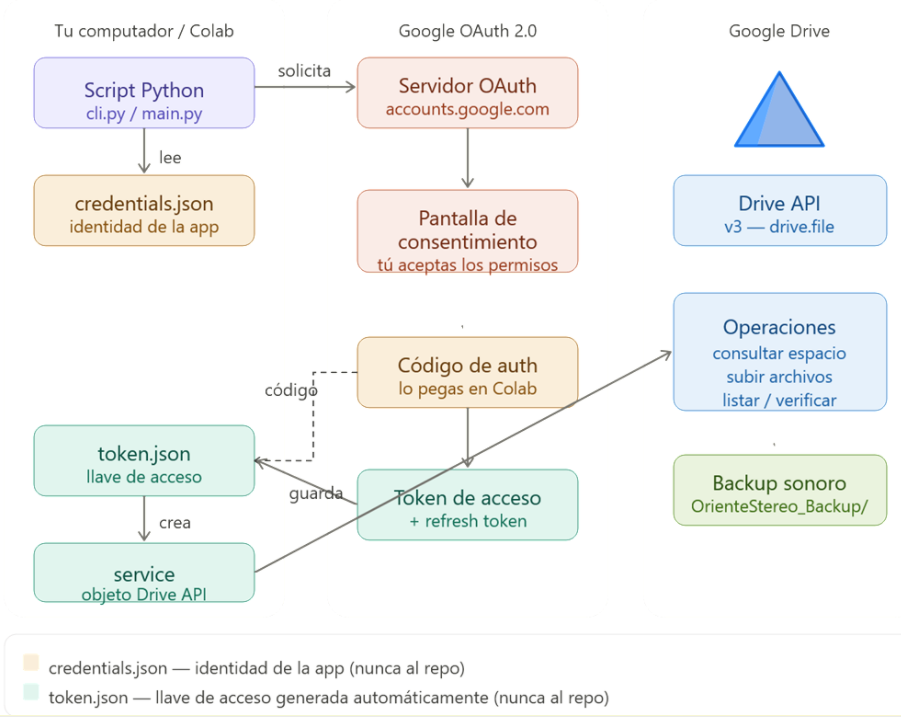

In [11]:
# Función de autenticación con detección automática de método

from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
import json, os
from pathlib import Path

SCOPES = ['https://www.googleapis.com/auth/drive.file']

def autenticar_drive():
    """
    Autentica con Google Drive API.

    Intenta en orden:
    1. Colab Secrets (para clase)
    2. credentials.json en disco (para la radio)

    Retorna:
        service: objeto de Drive API listo para usar
        None   : si no se encontraron credenciales
    """
    creds = None
    credentials_info = None

    # ── Intento 1: Colab Secrets ──────────────────────────
    try:
        from google.colab import userdata
        creds_str = userdata.get('DRIVE_CREDENTIALS_JSON')
        if creds_str:
            credentials_info = json.loads(creds_str)
            print("🔑 Credenciales cargadas desde Colab Secrets")
    except Exception:
        pass

    # ── Intento 2: archivo credentials.json en disco ──────
    if not credentials_info and Path("/content/credenciales.json").exists():
        with open("/content/credenciales.json") as f:
            credentials_info = json.load(f)
        print("🔑 Credenciales cargadas desde credentials.json")

    if not credentials_info:
        print("⚠️  No se encontraron credenciales.")
        print("   En Colab: agrega DRIVE_CREDENTIALS_JSON en los Secrets (🔑)")
        print("   En local: coloca credentials.json en esta carpeta")
        return None

    # ── Cargar token guardado si existe ───────────────────
    if Path("token.json").exists():
        creds = Credentials.from_authorized_user_file("token.json", SCOPES)
        print("🎟️  Token existente encontrado")

    # ── Renovar o crear token ─────────────────────────────
    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            print("🔄 Token vencido — renovando automáticamente...")
            creds.refresh(Request())
            print("✅ Token renovado")
        else:
            print("🌐 Primera autenticación — se abrirá el navegador...")
            flow = InstalledAppFlow.from_client_config(credentials_info, SCOPES)
            creds = flow.run_local_server(port=0)
            print("✅ Autenticación exitosa")

        # Guardar token para la próxima vez
        with open("token.json", "w") as f:
            f.write(creds.to_json())
        print("💾 Token guardado en token.json")

    service = build('drive', 'v3', credentials=creds)
    print("✅ Conexión a Drive API establecida")
    return service


# ── Ejecutar autenticación ────────────────────────────────
service = autenticar_drive()

🔑 Credenciales cargadas desde Colab Secrets
🎟️  Token existente encontrado
✅ Conexión a Drive API establecida


### ¿Qué contiene el `token.json` que se guardó?

```json
{
  "token": "ya29.A0...",          ← token de acceso (vence en 1 hora)
  "refresh_token": "1//0g...",    ← token de renovación (no vence)
  "expiry": "2026-03-18T15:30:00" ← cuándo vence el token de acceso
}
```

El `refresh_token` es lo más valioso: permite renovar el `token` sin volver a abrir el navegador.

> ⚠️ **En la radio**: el primer día configuramos la autenticación. Las veces siguientes, `python main.py --backup-drive` simplemente funciona sin que nadie tenga que iniciar sesión.

###**Recursos y Métodos de la API de Google Drive que vamos a usar**

`service.files()` : recurso principal para obtener y crear archivos y carpetas.
  1. `files().list()` : Listar archivos con filtros y búsquedad.
  2. `files().get()` : Obtiene los metadatos de un archivo.
  3. `files().create()`: crea un archivo o sube contenido nuevo.
  4. `files().update()`: Modifica el nombre, carpeta o contenido.
  
`service.about()` :Es uno de los recursos disponibles en la API. Contiene la informacion de la cuenta de usuario de google drive y el almacenamiento.
  1. `about().get()`


Mas informacion en la documentación: [**API DRIVE**](https://developers.google.com/resources/api-libraries/documentation/drive/v3/python/latest/index.html)

---
## 📊 Parte 4 — Consultar el espacio disponible en Drive
⏱ *15 minutos*

Antes de subir cualquier archivo, verificamos el espacio. El Drive de Oriente Stereo está al 80% — no podemos asumir que siempre habrá espacio.

usamos el metodo `service.about().get()` para verificar cuanto espacio nos queda.

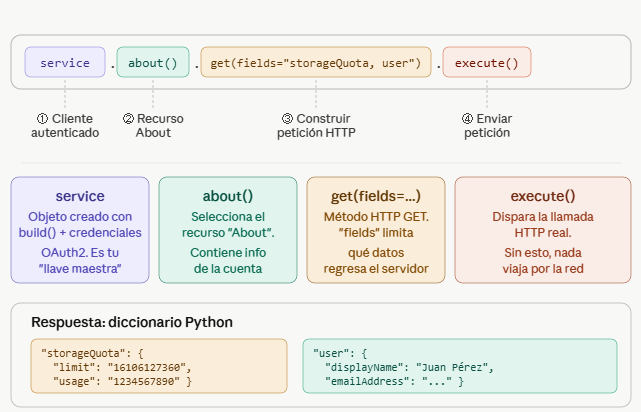

`.get(fields="storageQuota, user")` — Construir la petición

📚 Analogía: Es llenar un formulario de solicitud en la biblioteca. Escribes exactamente qué quieres: "solo necesito el espacio disponible y el nombre del usuario", en vez de pedir el expediente completo.

Dos cosas importantes aquí:


`get()` — indica que usarás el método HTTP GET (leer información, no modificar nada).

`fields`= — es el parámetro más importante. Le dice al servidor de Google qué campos incluir en la respuesta. Sin esto, Google devolvería todo (más datos = más tiempo + más bytes).

Los valores posibles para about son:

|Campo|Qué contiene |
|--|--|
|storageQuota |Límite total, usado, en papelera|
| user | Nombre, email, foto del usuario|
|appInstalled| Si tiene la app de Drive instalada|
|exportFormats | Formatos de exportación disponibles|
|importFormats | Formatos de importación soportados|
|maxImportSizes|Tamaño máximo por tipo de archivo|

⚠️ En este punto aún no viajó ningún byte por internet. .get() solo construye el objeto de la petición en memoria.

 **.execute()** — Disparar la petición real

📚 Analogía: Es el momento en que entregas el formulario en la ventanilla. Aquí sí hay movimiento real: sale una petición HTTPS a los servidores de Google, que la validan, consultan tu cuenta y te responden.

Internamente hace lo siguiente:




```
Tu código → HTTPS GET → googleapis.com/drive/v3/about?fields=storageQuota,user
```



                                    ↓
                         Google verifica el token OAuth2
                                    ↓
                         Devuelve JSON con solo los campos pedidos
                                    ↓
                    .execute() convierte ese JSON → dict de Python

**Tu turno:**
Imprime el almacenamiento que esta usado en tu google drive.

In [15]:
res = service.about().get(fields = "storageQuota").execute()

In [13]:
print(f" Almacenamiento usado : {round(int(res['storageQuota']['usage']) / (1024 ** 3), 2)} ")

 Almacenamiento usado : 128804.53 


Imprime el límite del plan que tienes en google drive:

```
res['storageQuota']['limit']
```


In [16]:
res['storageQuota']['limit']

'165253161680896'

**¿Cuánto almacenamiento te queda libre?**

Calcula los MB que te quedan libres de tu almacenamiento de drive.


In [22]:
quota = res['storageQuota']
total_bytes = int(quota.get('limit', 15 * 1024**3))
usado_bytes = int(quota.get('usage', 0))
libre_bytes = total_bytes - usado_bytes
lybre_bytes_mb = total_bytes / (1024 * 1024)

In [23]:
print(f" Almacenamiento libre : {round(libre_bytes / (1024 ** 2), 2)} ")
print(f" Almacenamiento libre : {round(lybre_bytes_mb, 2)} MB")

 Almacenamiento libre : 25701859.95 
 Almacenamiento libre : 157597696.0 MB


Imprime el almacenamiento usado sólo en drive:
```
res['storageQuota']['usageInDrive']
```



**También podemos ver la informacion del usuario: '`user`'**

Muestra en pantalla la informacion del usuario completa como su correo,foto.

In [27]:
res = service.about().get(fields = "user").execute()
userdata = res['user']
print(userdata)

{'kind': 'drive#user', 'displayName': 'LUZ ANGELA CARABALI MULATO', 'photoLink': 'https://lh3.googleusercontent.com/a/ACg8ocKOvX77fUtz4lOQA-_4VTwX4nIxfPsb62P7ZZiyYBz7T5jB1g=s64', 'me': True, 'permissionId': '09848336778858615257', 'emailAddress': 'luz_angela.carabali@uao.edu.co'}


In [24]:
def obtener_espacio_drive(service):
    """
    Consulta la cuota de almacenamiento del Drive conectado.

    Retorna:
        dict con total_gb, usado_gb, libre_mb, porcentaje_uso
        o None si no hay conexión
    """
    if service is None:
        # Simulamos el escenario real de Oriente Stereo: Drive al 80%
        print("⚠️  Sin conexión real — usando datos simulados del diagnóstico")
        total_bytes = 15 * 1024**3      # 15 GB (Drive gratuito)
        usado_bytes = int(total_bytes * 0.80)
        libre_bytes = total_bytes - usado_bytes
    else:
        try:
            about   = service.about().get(fields="storageQuota").execute()
            quota   = about['storageQuota']
            total_bytes = int(quota.get('limit', 15 * 1024**3))
            usado_bytes = int(quota.get('usage', 0))
            libre_bytes = total_bytes - usado_bytes
        except Exception as e:
            print(f"❌ Error al consultar espacio: {e}")
            return None

    resultado = {
        'total_gb':       round(total_bytes  / 1024**3, 2),
        'usado_gb':       round(usado_bytes  / 1024**3, 2),
        'libre_mb':       round(libre_bytes  / 1024**2, 1),
        'libre_gb':       round(libre_bytes  / 1024**3, 2),
        'porcentaje_uso': round(usado_bytes / total_bytes * 100, 1),
    }
    return resultado


def mostrar_espacio(info):
    """Imprime el resumen de espacio en formato legible."""
    if not info:
        return
    barra = int(info['porcentaje_uso'] / 5)  # barra de 20 caracteres
    barra_visual = '█' * barra + '░' * (20 - barra)

    print("┌─────────────────────────────────────────┐")
    print("│       ESPACIO EN GOOGLE DRIVE           │")
    print("├─────────────────────────────────────────┤")
    print(f"│  Total    : {info['total_gb']:>6.1f} GB                  │")
    print(f"│  Usado    : {info['usado_gb']:>6.1f} GB ({info['porcentaje_uso']}%)          │")
    print(f"│  Libre    : {info['libre_gb']:>6.2f} GB ({info['libre_mb']:.0f} MB)      │")
    print(f"│  [{barra_visual}] {info['porcentaje_uso']}%  │")
    print("└─────────────────────────────────────────┘")

    if info['porcentaje_uso'] >= 95:
        print("  🔴 CRÍTICO: Drive casi lleno. Backup imposible.")
    elif info['porcentaje_uso'] >= 80:
        print("  🟠 ALERTA: Drive al 80%+. Priorizar qué subir.")
    else:
        print("  🟢 Espacio suficiente para backup.")


# ── Consultar y mostrar ───────────────────────────────────
espacio = obtener_espacio_drive(service)
mostrar_espacio(espacio)

┌─────────────────────────────────────────┐
│       ESPACIO EN GOOGLE DRIVE           │
├─────────────────────────────────────────┤
│  Total    : 153904.0 GB                  │
│  Usado    : 128804.5 GB (83.7%)          │
│  Libre    : 25099.47 GB (25701860 MB)      │
│  [████████████████░░░░] 83.7%  │
└─────────────────────────────────────────┘
  🟠 ALERTA: Drive al 80%+. Priorizar qué subir.


###**Crear un archivo en drive**

####**Subir un archivo**



1. Importa la clase que sabe leer un archivo del disco y enviarlo a Google en partes. Sin esto no puedes subir nada:

`service.files().create() `solo crea metadatos, no mueve bytes.

In [ ]:
from googleapiclient.http import MediaFileUpload

In [ ]:
with open("BARRIO ADENTRO 06-06-25.txt", "w") as f:
    f.write("Prueba de backup — Oriente Stereo")

2. Crea un diccionario con la información sobre el archivo — no el archivo en sí.

In [ ]:
file_metadata = {
    "name": "BARRIO ADENTRO 06-06-25.txt",   # nombre que tendrá en Drive
    #"parents": ["id_de_la_carpeta"]            # carpeta destino en Drive
}

3. Prepara el archivo para ser enviado. No sube nada.

In [ ]:
media = MediaFileUpload("BARRIO ADENTRO 06-06-25.txt",  # dónde está el archivo en tu disco
    mimetype="text/plain",                      # qué tipo de archivo es
    resumable=True                              # permite reanudar si se corta
)

`resumable=True`: es crítico para

**Oriente Stereo**: si la conexión se corta a mitad de un archivo de **100 MB**, Drive guarda lo que llegó y el script puede continuar desde ahí en vez de empezar de cero.

4. Aquí sí ocurre la subida.

fields le dice a Drive qué datos incluir en la respuesta, si no lo especificas, devuelve todo y es mucho más lento.

`.execute()` dispara la petición HTTP. Sin esto, nada ocurre — es como preparar el formulario pero nunca enviarlo.

In [ ]:
archivo_subido = service.files().create(
    body=file_metadata,       # los metadatos (nombre, carpeta)
    media_body=media,         # el contenido real del archivo
    fields="id, name, size"   # qué información quieres que Drive te devuelva
).execute()

In [ ]:
archivo_subido

In [ ]:
from googleapiclient.http import MediaFileUpload

# Crear un archivo de prueba pequeño
with open("prueba_oriente.txt", "w") as f:
    f.write("Prueba de backup — Oriente Stereo")

# Subir
file_metadata = {"name": "prueba_oriente.txt"}
media = MediaFileUpload("prueba_oriente.txt", mimetype="text/plain")

archivo = service.files().create(
    body=file_metadata,
    media_body=media,
    fields="id, name"
).execute()

print(f"✅ Subido: {archivo['name']} → id: {archivo['id']}")

# Ahora sí aparece en la lista
results = service.files().list(fields="files(id, name)").execute()
items   = results.get("files", [])
for item in items:
    print(f"   → {item['name']} ({item['id']})")

####**Crear la carpeta en Drive**

1. Crear carpeta de backup en Drive

```python
#diccionario con los metadatos de la carpeta
carpeta_metadata = {
    "name":     "OrienteStereo_Backup",
    "mimeType": "application/vnd.google-apps.folder"  # esto le dice a Drive que es una carpeta
}
```






In [ ]:
#diccionario con los metadatos de la carpeta
carpeta_metadata = {
}

2. Realizar la subida.


```python
carpeta = service.files().create(
    body=carpeta_metadata,
    fields="id, name"
).execute()
```



In [ ]:
carpeta = service...

Obtener el ID de la carepta y guardarlo en un variable para usarlo luego.


```python
FOLDER_ID = carpeta["id"]
```

3. Subir el archivo a una carpeta especifica.Especificar con el ID de la carpeta antes creada.



```python
from googleapiclient.http import MediaFileUpload
from pathlib import Path

ruta  = "/content/BARRIO ADENTRO 06-06-25.txt"
path  = Path(ruta)

file_metadata = {
    "name":    path.name,
    "parents": [FOLDER_ID]   # ← ahora sí es el ID real


media = MediaFileUpload(str(path), mimetype="text/plain", resumable=True)

resultado = service.files().create(
    body=file_metadata,
    media_body=media,
    fields="id, name"
).execute()

print(f"✅ Subido: {resultado['name']}")
print(f"   ID en Drive: {resultado['id']}")

```




In [ ]:
#Escribe el ejemplo anterior aqui.
#cuando preparamos los datos o el archivoo que vamos a usar,
#en los metadatos agregamos el 'ID' de la carpeta a el argumento 'parents'



---
## 💿 Parte 5 — Recrear el disco de Oriente Stereo
⏱ *10 minutos*

Usamos la estructura real del diagnóstico para simular los archivos que vamos a respaldar.

In [ ]:
from pathlib import Path

RUTA_BASE = Path("sample_data/DISCO_PRUEBA/NUEVO ORIENTE ESTEREO/PROGRAMAS")

carpetas = [
    "A PRENDER LA ONDA",
    "BARRIO ADENTRO/PROGRAMAS",
    "CESAR PAGANO/SONGOROCOSONGO",
    "CESAR PAGANO/PAGANO BOLERO/2025",
    "DEJAME SER ARTE/PRODUCCION DSA",
    "DEJAME SER ARTE/PROGRAMAS",
    "DEJAME SER ARTE/MUSICA",
    "DIANA URIBE",
    "EN LA RAYA",
    "ENTRE NOSOTROS/2025",
    "ENTRE NOSOTROS/PROGRAMA 290 ENTRE NOSOTROS DE KAREN ARRANZ SABADO 24 DE FEBRERO DE 2026",
    "LA CHICHARRA/INFORMES",
    "LA CHICHARRA/PROGRAMAS",
    "FRECUENCIA UMBRELLA/MUSICA",
    "FREDY CORTES/CITA BOLERO",
    "FREDY CORTES/HORA SONORA",
    "HUMO EN LA RADIO/CARPETAS RAP/13-09-25",
]

# Tamaños simulados en bytes para cada archivo
archivos_sonoros = {
    "A PRENDER LA ONDA/EPISODIO 24-2025.mp3":                             45_000_000,
    "A PRENDER LA ONDA/Episodio 35 2025.mp3":                             38_000_000,
    "A PRENDER LA ONDA/Episodio 125.mp3":                                 52_000_000,
    "A PRENDER LA ONDA/Episodio 122 2023(1).mp3":                         41_000_000,
    "BARRIO ADENTRO/PROGRAMAS/BARRIO ADENTRO 06-06-25.mp3":               67_000_000,
    "CESAR PAGANO/SONGOROCOSONGO/SONGORO - leonor gonzalez mina.mp3":      88_000_000,
    "CESAR PAGANO/SONGOROCOSONGO/SONGORO - exotismos sonoros brasil.mp3":  91_000_000,
    "CESAR PAGANO/SONGOROCOSONGO/SONGORO - gerardo rosales PARTE 1.mp3":   75_000_000,
    "CESAR PAGANO/SONGOROCOSONGO/SONGORO - gerardo rosales PARTE 2.mp3":   78_000_000,
    "CESAR PAGANO/SONGOROCOSONGO/SONGOROCOSONGO - luis perico ortiz.mp3":  85_000_000,
    "CESAR PAGANO/PAGANO BOLERO/2025/PAGANO BOLERO - mujeres bolero.mp3":  62_000_000,
    "DEJAME SER ARTE/PRODUCCION DSA/CABEZOTE DSA.mp3":                      3_500_000,
    "DEJAME SER ARTE/PRODUCCION DSA/PISADOR DSA 1.mp3":                     1_200_000,
    "DEJAME SER ARTE/PROGRAMAS/DEJAME SER ARTE 03-07-25.mp3":              95_000_000,
    "DEJAME SER ARTE/PROGRAMAS/DEJAME SER ARTE17-07-25.mp3":               98_000_000,
    "DEJAME SER ARTE/MUSICA/insaic cancion 1.mp3":                          8_000_000,
    "DIANA URIBE/1 - La historia de la radio.mp3":                         55_000_000,
    "DIANA URIBE/2 - La radio en las guerras.mp3":                         58_000_000,
    "DIANA URIBE/3 - una radio diferente.mp3":                             53_000_000,
    "DIANA URIBE/7- Comienzos de la radio en Colombia.mp3":                60_000_000,
    "EN LA RAYA/EN LA RAYA DEPORTES 03 DE DIC DE 2025.mp3":               110_000_000,
    "EN LA RAYA/EN LA RAYA DEPORTES- AGOSTO 25 DE 2025.mp3":              108_000_000,
    "EN LA RAYA/EN LA RAYA DEPORTES- OCT 1 DE 2025.mp3":                  112_000_000,
    "EN LA RAYA/EN LA RAYA DEPORTES- OCT 03 DE 2025.mp3":                 109_000_000,
    "EN LA RAYA/En la Raya Deportes- Septiembre 29 de 2025.mp3":          105_000_000,
    "ENTRE NOSOTROS/PROGRAMA 290 ENTRE NOSOTROS DE KAREN ARRANZ SABADO 24 DE FEBRERO DE 2026/PROG.290 1RA MEDIA HORA.mp3": 28_000_000,
    "ENTRE NOSOTROS/2025/CUANDO PASE EL TEMBLOR.mp3":                      22_000_000,
    "LA CHICHARRA/INFORMES/VOCES DEL PACIFICO.mp4":                       145_000_000,
    "LA CHICHARRA/INFORMES/vanesa calle_mezcla.mp3":                       35_000_000,
    "FRECUENCIA UMBRELLA/MUSICA/Cancion de Tetris Original.mp3":             6_000_000,
    "FRECUENCIA UMBRELLA/MUSICA/MOMENTOS TENSOS.mp3":                        4_500_000,
    "FREDY CORTES/HORA SONORA/BLOQUE FINAL SONORA 29 MARZO.mp3":           48_000_000,
    "FREDY CORTES/CITA BOLERO/BLOQUE FINAL CITA 29 MARZO 2026.mp3":        51_000_000,
    "HUMO EN LA RADIO/CARPETAS RAP/13-09-25/01 - PRIMERA LINEA.mp3":        7_000_000,
    "HUMO EN LA RADIO/CARPETAS RAP/13-09-25/02- NO LOS LEO.mp3":            6_500_000,
    "HUMO EN LA RADIO/CARPETAS RAP/13-09-25/003--MI RAP.mp3":               8_200_000,
    "HUMO EN LA RADIO/CARPETAS RAP/13-09-25/04-A UD SENOR tema.mp3":        9_100_000,
}

# Crear estructura
for carpeta in carpetas:
    (RUTA_BASE / carpeta).mkdir(parents=True, exist_ok=True)

for ruta_rel, tam in archivos_sonoros.items():
    ruta = RUTA_BASE / ruta_rel
    ruta.parent.mkdir(parents=True, exist_ok=True)
    with open(ruta, 'wb') as f:
        f.write(b'0' * min(tam, 2048))   # escribimos solo 2 KB para no llenar Colab

print(f"✅ Disco simulado creado en: {RUTA_BASE}")
print(f"   Carpetas : {len(carpetas)}")
print(f"   Archivos : {len(archivos_sonoros)}")
print(f"   Tamaño total simulado: {sum(archivos_sonoros.values()) / 1024**2:.1f} MB")

---
## 📋 Parte 6 — Construir el catálogo desde el disco simulado
⏱ *20 minutos*

En S5 construimos `catalogo.py`. Hoy lo usamos directamente: leemos el disco, construimos el DataFrame y lo guardamos como CSV. Este CSV es el que la función de backup leerá para saber qué archivos respaldar.

In [ ]:
import pandas as pd
from pathlib import Path
from datetime import datetime

# ── Configuración de Oriente Stereo ──────────────────────
CARPETAS_EXCLUIDAS = [
    "MUSICA", "PRODUCCION DSA", "PRODUCCION",
    "ARCHIVOS AUDIO", "ARCHIVOS AUDIOS", "VISUALES"
]

CARPETAS_PROGRAMAS = {
    "A PRENDER LA ONDA":    "a_prender_la_onda",
    "BARRIO ADENTRO":       "barrio_adentro",
    "CESAR PAGANO":         "cesar_pagano",
    "DEJAME SER ARTE":      "dejame_ser_arte",
    "DIANA URIBE":          "diana_uribe",
    "EN LA RAYA":           "en_la_raya",
    "ENTRE NOSOTROS":       "entre_nosotros",
    "LA CHICHARRA":         "la_chicharra",
    "FRECUENCIA UMBRELLA":  "frecuencia_umbrella",
    "FREDY CORTES":         "fredy_cortes",
    "HUMO EN LA RADIO":     "humo_en_la_radio",
    "PAGANO BOLERO":        "pagano_bolero",
    "SONGOROCOSONGO":       "songorocosongo",
}

CONDUCTORES         = ["CESAR PAGANO", "FREDY CORTES"]
EXTENSIONES_AUDIO   = {".mp3", ".mp4"}

# Tamaños reales del archivo simulado (para la demo)
TAMAÑOS_REALES = {
    Path(k).name: v for k, v in archivos_sonoros.items()
}

def construir_catalogo(ruta_programas):
    """Escanea ruta_programas y devuelve el DataFrame del catálogo."""
    ruta_programas = Path(ruta_programas)
    filas = []

    archivos = [
        a for ext in EXTENSIONES_AUDIO
        for a in ruta_programas.rglob(f"*{ext}")
    ]

    for archivo in archivos:
        ruta_relativa    = archivo.relative_to(ruta_programas)
        directorio_padre = ruta_relativa.parent.name

        if directorio_padre in CARPETAS_EXCLUIDAS:
            continue

        # Buscar programa subiendo por ancestros
        programa_encontrado  = None
        conductor_encontrado = None
        ruta_actual          = ruta_relativa.parent

        while ruta_actual.name != "":
            if ruta_actual.name in CARPETAS_EXCLUIDAS:
                break
            if ruta_actual.name in CONDUCTORES and not conductor_encontrado:
                conductor_encontrado = ruta_actual.name
            if ruta_actual.name in CARPETAS_PROGRAMAS:
                programa_encontrado = ruta_actual.name
                break
            ruta_actual = ruta_actual.parent

        if not programa_encontrado:
            continue

        # Tamaño: real del disco, o simulado si está disponible
        nombre = archivo.name
        tamaño_bytes = TAMAÑOS_REALES.get(nombre, archivo.stat().st_size)
        tamaño_mb    = round(tamaño_bytes / (1024 * 1024), 2)

        stat  = archivo.stat()
        fecha = datetime.fromtimestamp(stat.st_mtime).strftime("%Y-%m-%d %H:%M:%S")

        filas.append({
            "nombre_programa":            programa_encontrado,
            "conductor":                  conductor_encontrado or "",
            "nombre_archivo_original":    nombre,
            "nombre_archivo_normalizado": "",          # S6
            "tipo_archivo":               archivo.suffix.lower(),
            "tamaño_mb":                  tamaño_mb,
            "ruta_sistema":               str(archivo.resolve()),
            "fecha_modificacion":         fecha,
            "tiene_backup":               False,
        })

    return pd.DataFrame(filas)


# ── Construir y guardar ───────────────────────────────────
print("🔍 Escaneando disco simulado de Oriente Stereo...")
df_catalogo = construir_catalogo(RUTA_BASE)

df_catalogo.to_csv(
    "catalogo_oriente.csv",
    index=False,
    encoding="utf-8-sig",
    na_rep=""
)

print(f"✅ Catálogo guardado: catalogo_oriente.csv")
print(f"   {len(df_catalogo)} archivos | {df_catalogo['tamaño_mb'].sum():.1f} MB total")
print()
df_catalogo[['nombre_programa','nombre_archivo_original','tamaño_mb','tiene_backup']]

In [ ]:
# ── Resumen por programa ─────────────────────────────────────
print("📊 Archivos por programa:")
resumen = (df_catalogo
    .groupby('nombre_programa')
    .agg(
        archivos=('nombre_archivo_original', 'count'),
        tamaño_total_mb=('tamaño_mb', 'sum')
    )
    .sort_values('tamaño_total_mb', ascending=False)
)
print(resumen.to_string())

---
## 📁 Parte 7 — Crear la carpeta de backup en Drive
⏱ *10 minutos*

Antes de subir archivos necesitamos una carpeta en Drive donde organizarlos. La creamos una sola vez y guardamos su ID.

In [ ]:
def obtener_o_crear_carpeta(service, nombre_carpeta, carpeta_padre_id=None):
    """
    Busca una carpeta en Drive por nombre. Si no existe, la crea.
    Evita duplicados si se llama varias veces.

    Parámetros:
        service: cliente Drive API
        nombre_carpeta (str): nombre de la carpeta
        carpeta_padre_id (str): ID de la carpeta padre (None = raíz del Drive)

    Retorna:
        str: ID de la carpeta en Drive
    """
    if service is None:
        print(f"🔵 [SIMULADO] Carpeta '{nombre_carpeta}' → id: carpeta_simulada_001")
        return "carpeta_simulada_001"

    # Buscar si ya existe
    query = f"name='{nombre_carpeta}' and mimeType='application/vnd.google-apps.folder' and trashed=false"
    if carpeta_padre_id:
        query += f" and '{carpeta_padre_id}' in parents"

    resultados = service.files().list(
        q=query,
        fields="files(id, name)"
    ).execute()

    archivos = resultados.get('files', [])
    if archivos:
        folder_id = archivos[0]['id']
        print(f"📁 Carpeta existente: '{nombre_carpeta}' → id: {folder_id}")
        return folder_id

    # Crear si no existe
    metadata = {
        'name':     nombre_carpeta,
        'mimeType': 'application/vnd.google-apps.folder',
    }
    if carpeta_padre_id:
        metadata['parents'] = [carpeta_padre_id]

    carpeta = service.files().create(body=metadata, fields='id').execute()
    folder_id = carpeta['id']
    print(f"✅ Carpeta creada: '{nombre_carpeta}' → id: {folder_id}")
    return folder_id


# ── Crear estructura de carpetas en Drive ─────────────────
print("📁 Configurando carpetas en Drive...")

# Carpeta raíz del backup
DRIVE_FOLDER_ID = obtener_o_crear_carpeta(service, "OrienteStereo_Backup")

# Carpeta por fecha de hoy
fecha_hoy = datetime.now().strftime("%Y-%m-%d")
DRIVE_FOLDER_HOY = obtener_o_crear_carpeta(
    service,
    f"backup_{fecha_hoy}",
    DRIVE_FOLDER_ID
)

print()
print(f"✅ Carpeta raíz ID : {DRIVE_FOLDER_ID}")
print(f"✅ Carpeta hoy ID  : {DRIVE_FOLDER_HOY}")

---
## ⬆️ Parte 8 — Subir un archivo a Drive: ejercicio real
⏱ *25 minutos*

Antes de subir la tanda completa, vamos a subir **un solo archivo** y entender cada paso del proceso.

### ¿Qué hace `MediaFileUpload`?

```python
from googleapiclient.http import MediaFileUpload

media = MediaFileUpload(
    "ruta/al/archivo.mp3",   # archivo local a subir
    mimetype="audio/mpeg",   # tipo MIME del archivo
    resumable=True           # permite reanudar si se corta la conexión
)
```

`resumable=True` es crítico para Oriente Stereo: la conexión a internet tiene limitaciones de subida. Si se corta a mitad de un archivo de 100 MB, `resumable=True` permite continuar desde donde quedó.

In [ ]:
from googleapiclient.http import MediaFileUpload

# Mapa de extensiones → tipo MIME
MIME_TYPES = {
    '.mp3':  'audio/mpeg',
    '.mp4':  'video/mp4',
}

def subir_archivo_drive(service, ruta_local, folder_id, nombre_destino=None):
    """
    Sube un archivo a Google Drive.

    Parámetros:
        service      : cliente Drive API
        ruta_local   : ruta local del archivo (str o Path)
        folder_id    : ID de la carpeta destino en Drive
        nombre_destino: nombre en Drive (por defecto: mismo nombre del archivo)

    Retorna:
        dict: {exito, id_drive, url, error}
    """
    path   = Path(ruta_local)
    nombre = nombre_destino or path.name

    # ── Modo simulado ─────────────────────────────────────
    if service is None:
        import time, random
        print(f"   🔵 [SIMULADO] Subiendo: {nombre}")
        time.sleep(0.1)
        if random.random() > 0.05:    # 95% de éxito simulado
            id_fake = f"1BxiMVs_{hash(nombre) % 9999:04d}"
            print(f"   ✅ Subido → id: {id_fake}")
            return {
                'exito': True,
                'id_drive': id_fake,
                'url': f"https://drive.google.com/file/d/{id_fake}/view",
                'error': None
            }
        else:
            return {'exito': False, 'id_drive': None, 'url': None,
                    'error': "ConnectionError simulado"}

    # ── Modo real ─────────────────────────────────────────
    if not path.exists():
        return {'exito': False, 'id_drive': None, 'url': None,
                'error': f"Archivo no encontrado: {ruta_local}"}

    try:
        mime = MIME_TYPES.get(path.suffix.lower(), 'application/octet-stream')

        file_metadata = {
            'name':    nombre,
            'parents': [folder_id],
        }
        media = MediaFileUpload(str(path), mimetype=mime, resumable=True)

        archivo_drive = service.files().create(
            body=file_metadata,
            media_body=media,
            fields='id, webViewLink'
        ).execute()

        return {
            'exito':    True,
            'id_drive': archivo_drive.get('id'),
            'url':      archivo_drive.get('webViewLink'),
            'error':    None
        }

    except Exception as e:
        return {'exito': False, 'id_drive': None, 'url': None, 'error': str(e)}


# ── Subir el primer archivo del catálogo como prueba ──────
print("🧪 PRUEBA: subir un archivo a Drive")
print()

primer_archivo = df_catalogo.iloc[0]
ruta_local     = primer_archivo['ruta_sistema']
nombre         = primer_archivo['nombre_archivo_original']
programa       = primer_archivo['nombre_programa']

print(f"   Programa : {programa}")
print(f"   Archivo  : {nombre}")
print(f"   Tamaño   : {primer_archivo['tamaño_mb']} MB")
print()

resultado = subir_archivo_drive(service, ruta_local, DRIVE_FOLDER_HOY)

print()
print(f"   Éxito    : {resultado['exito']}")
print(f"   ID Drive : {resultado['id_drive']}")
if resultado['url']:
    print(f"   URL      : {resultado['url']}")
if resultado['error']:
    print(f"   Error    : {resultado['error']}")

---
## 📦 Parte 9 — Subir una tanda verificando la cuota
⏱ *30 minutos*

Ahora subimos **varios archivos** verificando el espacio antes de cada uno, registrando el resultado en el log y actualizando el catálogo.

In [ ]:
def registrar_log(mensaje, archivo_log="log_backup_drive.txt"):
    """Agrega una línea al log con timestamp."""
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(archivo_log, "a", encoding="utf-8") as f:
        f.write(f"[{ts}] {mensaje}\n")


def subir_tanda_drive(df_tanda, service, folder_id, df_catalogo,
                      archivo_catalogo="catalogo_oriente.csv",
                      archivo_log="log_backup_drive.txt"):
    """
    Sube una tanda de archivos a Drive con verificación de cuota.

    Para cada archivo:
      1. Verifica que aún hay espacio en Drive
      2. Sube el archivo
      3. Registra éxito o fallo en el log
      4. Actualiza tiene_backup=True en el catálogo si fue exitoso

    Al final guarda el catálogo actualizado.

    Parámetros:
        df_tanda        : DataFrame con los archivos a subir
        service         : cliente Drive API
        folder_id       : ID carpeta destino
        df_catalogo     : catálogo completo para actualizar
        archivo_catalogo: ruta del CSV del catálogo
        archivo_log     : ruta del archivo de log

    Retorna:
        dict: {subidos, fallidos, df_catalogo}
    """
    if df_tanda is None or df_tanda.empty:
        print("⚠️  Tanda vacía — nada que subir")
        return {'subidos': 0, 'fallidos': 0, 'df_catalogo': df_catalogo}

    subidos  = 0
    fallidos = 0
    ts_ini   = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    registrar_log(f"=== INICIO TANDA ({len(df_tanda)} archivos) ===", archivo_log)

    print(f"☁️  Subiendo tanda a Google Drive")
    print(f"   Archivos en tanda: {len(df_tanda)}")
    print(f"   Carpeta destino  : {folder_id}")
    print()

    for idx, (_, fila) in enumerate(df_tanda.iterrows(), 1):
        nombre   = fila['nombre_archivo_original']
        ruta     = fila['ruta_sistema']
        tam_mb   = fila['tamaño_mb'] or 0

        print(f"  [{idx:02d}/{len(df_tanda):02d}] {nombre}")
        print(f"          {fila['nombre_programa']} | {tam_mb:.1f} MB")

        # ── Verificar espacio antes de cada archivo ───────
        espacio = obtener_espacio_drive(service)
        if espacio and espacio['libre_mb'] < tam_mb:
            msg = f"SIN ESPACIO: necesita {tam_mb:.1f} MB, disponible {espacio['libre_mb']:.1f} MB"
            print(f"          ⛔ {msg}")
            registrar_log(f"  ✗ {nombre} — {msg}", archivo_log)
            fallidos += 1
            continue

        # ── Subir ─────────────────────────────────────────
        resultado = subir_archivo_drive(service, ruta, folder_id)

        if resultado['exito']:
            subidos += 1
            # Actualizar catálogo en memoria
            mask = df_catalogo['nombre_archivo_original'] == nombre
            df_catalogo.loc[mask, 'tiene_backup'] = True
            registrar_log(
                f"  ✓ {nombre} → id:{resultado['id_drive']}",
                archivo_log
            )
        else:
            fallidos += 1
            print(f"          ❌ Error: {resultado['error']}")
            registrar_log(
                f"  ✗ {nombre} — {resultado['error']}",
                archivo_log
            )

    # ── Guardar catálogo con backups marcados ─────────────
    df_catalogo.to_csv(
        archivo_catalogo, index=False, encoding="utf-8-sig", na_rep=""
    )

    registrar_log(
        f"=== FIN: {subidos} OK / {fallidos} FALLO ===",
        archivo_log
    )

    print()
    print("─" * 50)
    print(f"✅ Tanda completada")
    print(f"   Subidos    : {subidos}")
    print(f"   Fallidos   : {fallidos}")
    print(f"   Catálogo actualizado: {archivo_catalogo}")

    return {'subidos': subidos, 'fallidos': fallidos, 'df_catalogo': df_catalogo}


# ── Prueba: subir los primeros 5 archivos del catálogo ───
tanda_prueba = df_catalogo.head(5).copy()

print("🧪 Subiendo tanda de prueba (5 archivos)...")
print()

resultado_tanda = subir_tanda_drive(
    tanda_prueba,
    service,
    DRIVE_FOLDER_HOY,
    df_catalogo
)

In [ ]:
# ── Ver el log generado ──────────────────────────────────────
print("📋 Log de backup:")
print("─" * 55)
try:
    with open("log_backup_drive.txt", encoding="utf-8") as f:
        print(f.read())
except FileNotFoundError:
    print("(log vacío — ejecuta la celda anterior primero)")

In [ ]:
# ── Ver catálogo actualizado ─────────────────────────────────
df_post = pd.read_csv("catalogo_oriente.csv", encoding="utf-8-sig", keep_default_na=False)

con_backup    = df_post[df_post['tiene_backup'] == True]
sin_backup    = df_post[df_post['tiene_backup'] == False]

print(f"📊 Estado del catálogo tras el backup:")
print(f"   Con backup  : {len(con_backup)}")
print(f"   Sin backup  : {len(sin_backup)}")
print()
print("Con backup:")
print(con_backup[['nombre_programa','nombre_archivo_original','tiene_backup']])

---
## 🧩 Parte 10 — Priorización de tandas: ejercicio abierto
⏱ *25 minutos — se desarrolla en clase*

### El problema

El Drive de Oriente Stereo tiene solo **~3 GB libres** (80% ocupado).
El catálogo tiene archivos que suman más de 3 GB.
No podemos subir todo. Necesitamos decidir **qué va primero**.

### Reglas de negocio para priorizar

Discutamos en clase cuáles de estas reglas aplican para Oriente Stereo:

| # | Regla | Razonamiento |
|---|-------|-------------|
| 1 | Archivos sin backup previo primero | Los que nunca se respaldaron tienen mayor riesgo |
| 2 | MP3 antes que MP4 | Mismo contenido, 5-10x menos espacio |
| 3 | Los más pequeños primero | Maximizar cantidad de archivos respaldados |
| 4 | Los más recientes primero | El material nuevo aún no fue escuchado — más difícil de recuperar |
| 5 | Por programa | ¿Hay programas más importantes que otros para la emisora? |

### Estructura de `generar_tanda()`

```python
def generar_tanda(df_catalogo, espacio_disponible_mb):
    """
    Selecciona qué archivos respaldar dado el espacio disponible.

    Parámetros:
        df_catalogo (pd.DataFrame): catálogo completo
        espacio_disponible_mb (float): MB disponibles en Drive

    Retorna:
        pd.DataFrame: subconjunto a respaldar, en orden de prioridad
    """
    # Paso 1: filtrar solo archivos SIN backup y CON ruta válida
    candidatos = df_catalogo[
        (df_catalogo['tiene_backup'] == False) &
        (df_catalogo['nombre_archivo_original'] != "")
    ].copy()

    # Paso 2: agregar columna de prioridad
    # ← AQUÍ DESARROLLAMOS EN CLASE

    # Paso 3: ordenar por prioridad
    # ← AQUÍ DESARROLLAMOS EN CLASE

    # Paso 4: acumular archivos hasta llenar el espacio
    # ← AQUÍ DESARROLLAMOS EN CLASE

    pass
```

In [ ]:
# ── Exploración previa: conocer los datos antes de priorizar ─

df = pd.read_csv("catalogo_oriente.csv", encoding="utf-8-sig", keep_default_na=False)

print("📊 Distribución por tipo de archivo:")
print(df.groupby('tipo_archivo').agg(
    cantidad=('nombre_archivo_original','count'),
    tamaño_total_mb=('tamaño_mb','sum')
).round(1))

print()
print("📊 Archivos ordenados de mayor a menor tamaño:")
print(df[['nombre_programa','nombre_archivo_original','tamaño_mb','tipo_archivo']]
      .sort_values('tamaño_mb', ascending=False)
      .to_string(index=False))

In [ ]:
# ── Espacio disponible simulado (diagnóstico real: 80% ocupado) ─
ESPACIO_DISPONIBLE_MB = espacio['libre_mb'] if espacio else 3_000

print(f"💾 Espacio disponible para backup: {ESPACIO_DISPONIBLE_MB:.0f} MB")
print(f"   ({ESPACIO_DISPONIBLE_MB/1024:.2f} GB)")
print()

sin_backup = df[df['tiene_backup'] == False]
tamaño_sin_backup = sin_backup['tamaño_mb'].sum()

print(f"📦 Archivos sin backup: {len(sin_backup)}")
print(f"   Tamaño total       : {tamaño_sin_backup:.1f} MB ({tamaño_sin_backup/1024:.2f} GB)")
print()

if tamaño_sin_backup > ESPACIO_DISPONIBLE_MB:
    diferencia = tamaño_sin_backup - ESPACIO_DISPONIBLE_MB
    print(f"⚠️  No caben todos. Faltan {diferencia:.0f} MB ({diferencia/1024:.2f} GB).")
    print("   Necesitamos priorizar.")
else:
    print("✅ Caben todos los archivos pendientes.")

In [ ]:
# ══════════════════════════════════════════════════════════
# EJERCICIO ABIERTO: implementar generar_tanda()
# Discutir en clase qué criterios usar y en qué orden
# ══════════════════════════════════════════════════════════

def generar_tanda(df_catalogo, espacio_disponible_mb):
    """
    Selecciona qué archivos respaldar dado el espacio disponible.

    Parámetros:
        df_catalogo (pd.DataFrame): catálogo completo
        espacio_disponible_mb (float): MB disponibles en Drive

    Retorna:
        pd.DataFrame: archivos seleccionados para la tanda
    """
    # Paso 1: candidatos — sin backup, con archivo real
    candidatos = df_catalogo[
        (df_catalogo['tiene_backup'] == False) &
        (df_catalogo['nombre_archivo_original'] != "")
    ].copy()

    if candidatos.empty:
        print("✅ No hay archivos pendientes de backup.")
        return pd.DataFrame()

    # ← TU CÓDIGO EN CLASE:
    # Paso 2: columna de prioridad
    # Opciones a discutir:
    #   a) Por tipo: mp3=1, mp4=2, resto=3
    #   b) Por tamaño: los más pequeños primero (ascending=True)
    #   c) Por fecha: los más recientes primero (ascending=False)
    #   d) Combinación de las anteriores

    # Paso 3: ordenar
    # candidatos = candidatos.sort_values(...)

    # Paso 4: acumular hasta llenar el espacio
    tanda         = []
    espacio_usado = 0.0

    for _, fila in candidatos.iterrows():
        tam = fila['tamaño_mb'] if pd.notna(fila['tamaño_mb']) else 0
        if espacio_usado + tam <= espacio_disponible_mb:
            tanda.append(fila)
            espacio_usado += tam

    df_tanda = pd.DataFrame(tanda)

    print(f"📦 Tanda generada:")
    print(f"   Archivos seleccionados : {len(df_tanda)}")
    print(f"   Espacio que usará      : {espacio_usado:.1f} MB de {espacio_disponible_mb:.0f} MB disponibles")
    print(f"   Archivos que no entran : {len(candidatos) - len(df_tanda)}")

    return df_tanda


# ── Probar con los datos actuales ─────────────────────────
print("🧪 Probando generar_tanda() con catálogo actual:")
df_actual = pd.read_csv("catalogo_oriente.csv", encoding="utf-8-sig", keep_default_na=False)
tanda = generar_tanda(df_actual, ESPACIO_DISPONIBLE_MB)
if not tanda.empty:
    print()
    print(tanda[['nombre_programa','nombre_archivo_original','tamaño_mb']].to_string(index=False))

---
## 🚀 Parte 11 — Flujo completo: leer catálogo → tanda → subir → actualizar
⏱ *15 minutos*

Este es el flujo que correrá en la radio con `python main.py --backup-drive`.

In [ ]:
def backup_drive_completo(ruta_catalogo="catalogo_oriente.csv",
                          archivo_log="log_backup_drive.txt"):
    """
    Flujo completo de backup a Google Drive:
    1. Leer catálogo
    2. Consultar espacio disponible
    3. Generar tanda priorizada
    4. Subir tanda
    5. Actualizar catálogo

    Retorna:
        dict: resumen del backup
    """
    print("=" * 55)
    print("☁️  BACKUP GOOGLE DRIVE — ORIENTE STEREO")
    print("=" * 55)
    print()

    # 1. Leer catálogo
    if not Path(ruta_catalogo).exists():
        print("❌ Catálogo no encontrado. Ejecuta construir_catalogo() primero.")
        return
    df = pd.read_csv(ruta_catalogo, encoding="utf-8-sig", keep_default_na=False)
    print(f"📂 Catálogo leído: {len(df)} registros")

    # 2. Espacio disponible
    espacio = obtener_espacio_drive(service)
    mostrar_espacio(espacio)
    espacio_mb = espacio['libre_mb'] if espacio else 3000

    # 3. Generar tanda
    print()
    tanda = generar_tanda(df, espacio_mb)
    if tanda.empty:
        return {'subidos': 0, 'fallidos': 0}

    # 4. Subir tanda
    print()
    resultado = subir_tanda_drive(tanda, service, DRIVE_FOLDER_HOY, df, ruta_catalogo, archivo_log)

    # 5. Resumen final
    print()
    df_final = pd.read_csv(ruta_catalogo, encoding="utf-8-sig", keep_default_na=False)
    print("📊 Estado final del catálogo:")
    print(f"   Con backup  : {(df_final['tiene_backup']==True).sum()}")
    print(f"   Sin backup  : {(df_final['tiene_backup']==False).sum()}")

    return resultado


# ── Ejecutar flujo completo ───────────────────────────────
backup_drive_completo()

---
## 🔒 Parte 12 — Seguridad: cómo configurar esto en la radio
⏱ *10 minutos — preguntas frecuentes*

### ¿Hay que repetir la autenticación cada vez que corre el backup?

**No.** La primera vez sí hay que abrir el navegador. Después, `token.json` permite renovar automáticamente sin intervención.

```
Primera vez  → abre el navegador, el operador de la radio acepta
Después      → python main.py --backup-drive   (corre solo)
```

### ¿Qué pasa si alguien roba el computador de la radio?

Si roban el computador y tienen acceso al sistema de archivos:
- Pueden usar `token.json` para acceder al Drive de la emisora
- Por eso el computador debe tener contraseña de inicio de sesión
- Y el Drive solo debe tener acceso a la carpeta de backup (scope `drive.file`)

```python
# Con drive.file, el atacante solo ve los archivos que subió el script.
# No puede ver fotos personales, emails, ni otros documentos del Drive.
SCOPES = ['https://www.googleapis.com/auth/drive.file']
```

### ¿Cómo revocar el acceso si algo sale mal?

```
1. Ir a: https://myaccount.google.com/permissions
2. Encontrar "OrienteStereoBackup"
3. Clic en "Quitar acceso"
```

El `token.json` local queda inútil inmediatamente. Nadie puede acceder al Drive con él.

### ¿Qué va en `.gitignore`?

```
# Archivo .gitignore — OBLIGATORIO
credentials.json
token.json
*.env
.env
```

Ejecuta esto una sola vez para verificar que están excluidos:
```bash
git check-ignore -v credentials.json token.json
```

---
## ✅ Verificaciones finales

In [ ]:
# ── Verificación: todo el flujo funcionó ─────────────────────
print("🔍 VERIFICACIÓN FINAL — Sesiones 7 + 8")
print("=" * 55)

checks = []

# 1. Catálogo existe
cat_ok = Path("catalogo_oriente.csv").exists()
checks.append(cat_ok)
print(f"{'✅' if cat_ok else '❌'} catalogo_oriente.csv existe")

# 2. Log existe
log_ok = Path("log_backup_drive.txt").exists()
checks.append(log_ok)
print(f"{'✅' if log_ok else '❌'} log_backup_drive.txt existe")

# 3. Al menos un archivo tiene backup
df_check = pd.read_csv("catalogo_oriente.csv", encoding="utf-8-sig", keep_default_na=False)
backup_ok = (df_check['tiene_backup'] == True).sum() > 0
checks.append(backup_ok)
print(f"{'✅' if backup_ok else '❌'} Al menos un archivo marcado con backup")

# 4. Sin NaN en el CSV
csv_text = Path("catalogo_oriente.csv").read_text(encoding="utf-8-sig")
nan_ok   = "NaN" not in csv_text
checks.append(nan_ok)
print(f"{'✅' if nan_ok else '❌'} CSV sin texto 'NaN'")

# 5. Función generar_tanda definida
tanda_ok = 'generar_tanda' in dir()
checks.append(tanda_ok)
print(f"{'✅' if tanda_ok else '❌'} generar_tanda() definida")

print()
aprobados = sum(checks)
print(f"Resultado: {aprobados}/{len(checks)} verificaciones aprobadas")
if aprobados == len(checks):
    print("🎉 Sesiones 7 y 8 completadas correctamente")

---
## 📤 Commit del día

```bash
# Asegurarse de que las claves están en .gitignore
echo "credentials.json" >> .gitignore
echo "token.json"       >> .gitignore

git add catalogo_oriente.csv
git add log_backup_drive.txt
git add S7S8_GoogleDrive_API_OrienteStereo.ipynb
git commit -m "S7+S8: Drive API + autenticación OAuth2 + subir_tanda + generar_tanda"
git push
```

> ⚠️ **Verificar antes del push:** `git status` no debe mostrar `credentials.json` ni `token.json`

---

## ➡️ En S9+S10 vamos a...

```python

# main.py — sistema completo desde la consola
python main.py --estado
python main.py --backup-drive
```

---
*Python Schools 2026 · Cali, Colombia · Distrito de Agua Blanca*
*"El conocimiento técnico no tiene dueño. El código libre es cultura libre."*